In [ ]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt #
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive
from datetime import datetime
import math

drive.mount('/content/drive')

print("Imports chargés et Drive monté")

Mounted at /content/drive
Imports chargés et Drive monté


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path


N_BANDS = 10          # ex. Sentinel-2 : 10 bandes
N_TIMESTEPS = 36      # nombre de dates
N_HEAD = 5
LEARNING_RATE = 0.001
EPOCHS = 100
BATCH_SIZE = 32


run_dir = Path("./runs/mctnet_plus")
run_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
BATCH_SIZE = 64
EPOCHS = 200
LEARNING_RATE = 0.001
N_TIMESTEPS = 36
N_BANDS = 10

# Paramètres MCTNet
N_STAGES = 3
N_HEAD = 5
KERNEL_SIZE = 3
HIDDEN_DIM = None

# Optimizer
OPTIMIZER = 'Adam'

# Chemins
PROCESSED_PATH = Path('/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/data/processed')
RAW_DATA_PATH = Path('/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/data/raw')
OUTPUTS_PATH = Path('/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs')

In [ ]:
def load_data_with_correct_split(state_name):
    """
    Charge les données avec le split conforme à l'article
    """
    state_dir = PROCESSED_PATH / state_name.lower()

    # Charger les données NPZ
    train_data = np.load(state_dir / 'train.npz', allow_pickle=True)
    val_data = np.load(state_dir / 'val.npz', allow_pickle=True)
    test_data = np.load(state_dir / 'test.npz', allow_pickle=True)

    X_train, y_train = train_data['X'], train_data['y']
    X_val, y_val = val_data['X'], val_data['y']
    X_test, y_test = test_data['X'], test_data['y']

    # Charger metadata
    with open(state_dir / 'metadata.json', 'r') as f:
        metadata = json.load(f)



    # Étape 1 : INDICE → CODE CDL
    idx_to_code = {int(k): int(v) for k, v in metadata['idx_to_class'].items()}

    # Étape 2 : Définir les codes CDL principaux pour cet état
    if state_name.lower() == 'arkansas':
        MAIN_CODES = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans'}
    else:  # california
        MAIN_CODES = {1: 'Grapes', 2: 'Rice', 3: 'Alfalfa', 4: 'Almonds', 5: 'Pistachios'}

    # Étape 3
    def convert_to_name(y_array):
        names = []
        for idx in y_array:
            code = idx_to_code.get(int(idx), -1)
            name = MAIN_CODES.get(code, 'Others')
            names.append(name)
        return np.array(names)

    y_train_names = convert_to_name(y_train)
    y_val_names = convert_to_name(y_val)
    y_test_names = convert_to_name(y_test)

    # ============================================

    print(f"\n{state_name}:")
    print(f"   - Train: {X_train.shape[0]} samples")
    print(f"   - Val: {X_val.shape[0]} samples")
    print(f"   - Test: {X_test.shape[0]} samples")
    print(f"   - Shape: {X_train.shape[1]} timesteps, {X_train.shape[2]} bands")

    # Afficher la distribution RÉELLE
    print(f"\n   Distribution RÉELLE (train) :")
    for cls in list(MAIN_CODES.values()) + ['Others']:
        count = np.sum(y_train_names == cls)
        if count > 0:
            print(f"      {cls}: {count}")

    # Retourner aussi les noms déjà convertis
    metadata['y_train_names'] = y_train_names
    metadata['y_val_names'] = y_val_names
    metadata['y_test_names'] = y_test_names
    metadata['main_classes'] = list(MAIN_CODES.values()) + ['Others']

    return X_train, y_train, X_val, y_val, X_test, y_test, metadata

**ENTRAINEMENT MODEL**

In [ ]:
# ============================================================
# CELLULE 1 — DÉFINITION DU MODÈLE MCTNet++
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math

# ── ECA (inchangé) ──────────────────────────────────────────
class ECA(nn.Module):
    def __init__(self, d_model, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log(d_model, 2) + b) / gamma))
        kernel_size = max(t if t % 2 else t + 1, 3)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1)
        y = self.conv(y.unsqueeze(1)).squeeze(1)
        return x * self.sigmoid(y).unsqueeze(-1)


# ── ALPE (inchangé) ─────────────────────────────────────────
class ALPE(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size // 2)
        self.eca    = ECA(d_model)

    def forward(self, pe, mask):
        pe = pe * mask.unsqueeze(-1)
        x  = self.conv1d(pe.transpose(1, 2))
        x  = self.eca(x)
        return x.transpose(1, 2)


# ── NOUVEAU : Multi-Scale CNN ────────────────────────────────

class MultiScaleCNN(nn.Module):
    def __init__(self, d_model, dropout_rate=0.4):
        super().__init__()
        self.branch3 = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=7, padding=3),
            nn.BatchNorm1d(d_model), nn.ReLU()
        )
        self.fusion  = nn.Sequential(
            nn.Conv1d(d_model * 3, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model)
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.relu    = nn.ReLU()

    def forward(self, x):
        z   = x.transpose(1, 2)
        out = torch.cat([self.branch3(z),
                         self.branch5(z),
                         self.branch7(z)], dim=1)
        out = self.relu(self.fusion(out) + z)
        return self.dropout(out).transpose(1, 2)


# ── Transformer Sub-Module (GELU + FFN x4) ──────────────────
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, use_alpe=False, seq_len=36, dropout_rate=0.4):
        super().__init__()
        self.use_alpe = use_alpe
        self.d_model  = d_model
        self.nhead    = nhead

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)

        if use_alpe:
            self.alpe = ALPE(d_model)

        self.register_buffer('pe', self._sinusoidal(seq_len, d_model))

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(d_model * 4, d_model)
        )
        self.norm1    = nn.LayerNorm(d_model)
        self.norm2    = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.attn_weights = None

    @staticmethod
    def _sinusoidal(seq_len, d_model):
        pe  = torch.zeros(seq_len, d_model)
        pos = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe

    def forward(self, x, mask=None):
        B, T, D = x.shape
        if self.use_alpe and mask is not None:
            pe = self.pe.unsqueeze(0).expand(B, -1, -1)
            x  = x + self.alpe(pe, mask)
        else:
            x = x + self.pe.unsqueeze(0)

        Q = self.W_q(x); K = self.W_k(x); V = self.W_v(x)
        head_dim = D // self.nhead
        Q = Q.view(B, T, self.nhead, head_dim).transpose(1, 2)
        K = K.view(B, T, self.nhead, head_dim).transpose(1, 2)
        V = V.view(B, T, self.nhead, head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (head_dim ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1).unsqueeze(1) == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        self.attn_weights = attn.detach()

        out = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, D)
        out = self.W_o(out)
        x   = self.norm1(x + self.dropout1(out))
        x   = self.norm2(x + self.dropout2(self.ffn(x)))
        return x, attn


# ── NOUVEAU : SE Block ───────────────────────────────────────

class SEBlock(nn.Module):
    def __init__(self, d_model, reduction=4):
        super().__init__()
        hidden = max(d_model // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(d_model, hidden), nn.ReLU(),
            nn.Linear(hidden, d_model), nn.Sigmoid()
        )

    def forward(self, x):
        w = x.mean(dim=1)
        w = self.fc(w).unsqueeze(1)
        return x * w


# ── NOUVEAU : CT Fusion ────────────────────────────────
class GatedCTFusion(nn.Module):
    def __init__(self, input_dim, hidden_dim, nhead,
                 use_alpe=False, seq_len=36, dropout_rate=0.4):
        super().__init__()
        self.proj        = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.cnn         = MultiScaleCNN(hidden_dim, dropout_rate)
        self.transformer = TransformerSubModule(hidden_dim, nhead, use_alpe, seq_len, dropout_rate)
        self.gate        = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.Sigmoid()
        )
        self.se       = SEBlock(hidden_dim * 2)
        self.out_proj = nn.Linear(hidden_dim * 2, hidden_dim * 2)

    def forward(self, x, mask=None):
        x        = self.proj(x)
        cnn_out  = self.cnn(x)
        trans_out, _ = self.transformer(x, mask)

        combined = torch.cat([cnn_out, trans_out], dim=-1)
        g        = self.gate(combined)
        fused    = g * cnn_out + (1 - g) * trans_out

        # SE sur la concaténation complète
        out = self.se(combined)
        return self.out_proj(out)                            # (B, T, 2H)


# ── MCTNet++ ──────────────────────────────────
class MCTNetPlus(nn.Module):
    def __init__(self, input_dim=10, seq_len=36, num_classes=6,
                 nhead=5, dropout_rate=0.4,
                 h1=10, h2=20, h3=40):
        super().__init__()


        self.h1, self.h2, self.h3 = h1, h2, h3

        self.stage1 = GatedCTFusion(input_dim, h1, nhead,
                                    use_alpe=True, seq_len=seq_len, dropout_rate=dropout_rate)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage2 = GatedCTFusion(h1 * 2, h2, nhead,
                                    use_alpe=False, seq_len=seq_len//2, dropout_rate=dropout_rate)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage3 = GatedCTFusion(h2 * 2, h3, nhead,
                                    use_alpe=False, seq_len=seq_len//4, dropout_rate=dropout_rate)

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(h3 * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )


    def forward(self, x, mask):
        x = self.stage1(x, mask)
        x = self.pool1(x.transpose(1, 2)).transpose(1, 2)
        x = self.stage2(x, mask=None)
        x = self.pool2(x.transpose(1, 2)).transpose(1, 2)
        x = self.stage3(x, mask=None)
        x = self.global_pool(x.transpose(1, 2)).squeeze(-1)
        return self.classifier(x)


# ── Label Smoothing Loss ─────────────────────────────────────
class LabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.num_classes - 1)
        one_hot    = torch.full_like(pred, smooth_val)
        one_hot.scatter_(1, target.unsqueeze(1), confidence)
        log_prob   = F.log_softmax(pred, dim=-1)
        return -(one_hot * log_prob).sum(dim=-1).mean()


# ── Fonctions d'entraînement ─────────────────────────────────
def create_mask(x):
    return (x.abs().sum(dim=-1) > 0).float()

def train_epoch_plus(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        mask = create_mask(X)
        optimizer.zero_grad()
        out  = model(X, mask)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, pred = out.max(1)
        total   += y.size(0)
        correct += pred.eq(y).sum().item()
    return total_loss / len(loader), correct / total

def evaluate_plus(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            mask = create_mask(X)
            out  = model(X, mask)
            loss = criterion(out, y)
            total_loss += loss.item()
            _, pred = out.max(1)
            total   += y.size(0)
            correct += pred.eq(y).sum().item()
    return total_loss / len(loader), correct / total

print(" MCTNet++ défini avec succès !")


_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_model  = MCTNetPlus(input_dim=N_BANDS, seq_len=N_TIMESTEPS, num_classes=6, nhead=N_HEAD).to(_device)
_x      = torch.randn(4, N_TIMESTEPS, N_BANDS).to(_device)
_mask   = create_mask(_x)
_out    = _model(_x, _mask)
print(f" Test forward pass OK — output shape: {_out.shape}")
print(f"   Paramètres entraînables : {sum(p.numel() for p in _model.parameters() if p.requires_grad):,}")
del _model, _x, _mask, _out



 MCTNet++ défini avec succès !
 Test forward pass OK — output shape: torch.Size([4, 6])
   Paramètres entraînables : 93,180


# **ARKANSAS + MODEL ARKANSAS**

In [ ]:



# ============================================
# FONCTION train_state
# ============================================
def train_state(model, train_loader, val_loader, test_loader, device, state_name,
                num_classes, smoothing=0.1, epochs=200, lr=0.0005, weight_decay=1e-3):
    """
    Entraîne un modèle, évalue sur val et test, retourne modèle, historique, métriques, matrice confusion.
    """
    criterion = LabelSmoothingLoss(num_classes=num_classes, smoothing=smoothing)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    best_val_acc = 0
    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch_plus(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_plus(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{state_name.lower()}_mctnetplus.pth')

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | Best Val Acc: {best_val_acc:.4f}")

    print(f"\n Meilleure validation {state_name}: Acc = {best_val_acc:.4f}, Loss = {best_val_loss:.4f}")


    model.load_state_dict(torch.load(f'best_{state_name.lower()}_mctnetplus.pth'))
    test_loss, test_acc = evaluate_plus(model, test_loader, criterion, device)


    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            mask = create_mask(X)
            out = model(X, mask)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=[f"Class_{i}" for i in range(num_classes)])

    metrics = {'test_loss': test_loss, 'test_acc': test_acc, 'confusion_matrix': cm, 'report': report}

    return model, history, metrics, cm

# ============================================
# 1. CHARGEMENT DES DONNÉES ARKANSAS
# ============================================
print("\n" + "="*60)
print("ENTRAÎNEMENT MCTNet++ - ARKANSAS")
print("="*60)


# Classes cibles
target_classes = ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']


X_train, _, X_val, _, X_test, _, metadata = load_data_with_correct_split("arkansas")

y_train_raw = metadata['y_train_names']
y_val_raw   = metadata['y_val_names']
y_test_raw  = metadata['y_test_names']

train_mask = np.isin(y_train_raw, target_classes)
val_mask   = np.isin(y_val_raw, target_classes)
test_mask  = np.isin(y_test_raw, target_classes)

X_train_f = X_train[train_mask]
y_train_f = y_train_raw[train_mask]
X_val_f   = X_val[val_mask]
y_val_f   = y_val_raw[val_mask]
X_test_f  = X_test[test_mask]
y_test_f  = y_test_raw[test_mask]

print(f"Après filtrage pour {target_classes}:")
print(f"   Train: {X_train_f.shape[0]} samples")
print(f"   Val  : {X_val_f.shape[0]} samples")
print(f"   Test : {X_test_f.shape[0]} samples")

# Convertir les noms en indices
class_to_idx = {cls: i for i, cls in enumerate(target_classes)}
y_train = np.array([class_to_idx[name] for name in y_train_f])
y_val   = np.array([class_to_idx[name] for name in y_val_f])
y_test  = np.array([class_to_idx[name] for name in y_test_f])
num_classes = len(target_classes)

print(f"\nDistribution des classes après filtrage (train) :")
for cls in target_classes:
    cnt = np.sum(y_train_f == cls)
    print(f"   {cls}: {cnt}")

# ============================================
# 2. NORMALISATION DES DONNÉES
# ============================================
#
means = X_train_f.mean(axis=(0, 1))
stds  = X_train_f.std(axis=(0, 1))

X_train_norm = (X_train_f - means) / (stds + 1e-8)
X_val_norm   = (X_val_f - means) / (stds + 1e-8)
X_test_norm  = (X_test_f - means) / (stds + 1e-8)

# ============================================
# 3. DATALOADERS
# ============================================
BATCH_SIZE = 32

train_dataset = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y_train))
val_dataset   = TensorDataset(torch.FloatTensor(X_val_norm),   torch.LongTensor(y_val))
test_dataset  = TensorDataset(torch.FloatTensor(X_test_norm),  torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ark = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================
# 4. INSTANCIATION DU MODÈLE MCTNet++
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")


model = MCTNetPlus(
    input_dim   = X_train_norm.shape[2],
    seq_len     = X_train_norm.shape[1],
    num_classes = num_classes,
    nhead       = 5,
    dropout_rate= 0.6
).to(device)

print(f"Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

# ============================================
# 5. ENTRAÎNEMENT
# ============================================
EPOCHS = 200
LR = 0.0005
WEIGHT_DECAY = 1e-3

model_plus_ark, history_plus, metrics_plus, cm_plus = train_state(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader_ark,
    device=device,
    state_name="Arkansas",
    num_classes=num_classes,
    smoothing=0.1,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print(f"\nTest Acc MCTNet++ Arkansas : {metrics_plus['test_acc']:.4f}")
print("\nClassification Report :")
print(metrics_plus['report'])




ENTRAÎNEMENT MCTNet++ - ARKANSAS

arkansas:
   - Train: 1200 samples
   - Val: 300 samples
   - Test: 8500 samples
   - Shape: 36 timesteps, 10 bands

   Distribution RÉELLE (train) :
      Corn: 240
      Cotton: 240
      Rice: 240
      Soybeans: 240
      Others: 240
Après filtrage pour ['Soybeans', 'Rice', 'Corn', 'Cotton', 'Others']:
   Train: 1200 samples
   Val  : 300 samples
   Test : 8500 samples

Distribution des classes après filtrage (train) :
   Soybeans: 240
   Rice: 240
   Corn: 240
   Cotton: 240
   Others: 240

Device: cpu
Nombre de paramètres: 93,051
Epoch  20/200 | Train Loss: 0.7855 Acc: 0.8550 | Val Loss: 0.7522 Acc: 0.8033 | Best Val Acc: 0.8033
Epoch  40/200 | Train Loss: 0.6092 Acc: 0.9583 | Val Loss: 0.6050 Acc: 0.9200 | Best Val Acc: 0.9500
Epoch  60/200 | Train Loss: 0.5745 Acc: 0.9717 | Val Loss: 0.5779 Acc: 0.9433 | Best Val Acc: 0.9600
Epoch  80/200 | Train Loss: 0.5547 Acc: 0.9808 | Val Loss: 0.5423 Acc: 0.9633 | Best Val Acc: 0.9667
Epoch 100/200 | Tra

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Graphique sauvegardé dans : /content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs/arkansas_training_curves.png


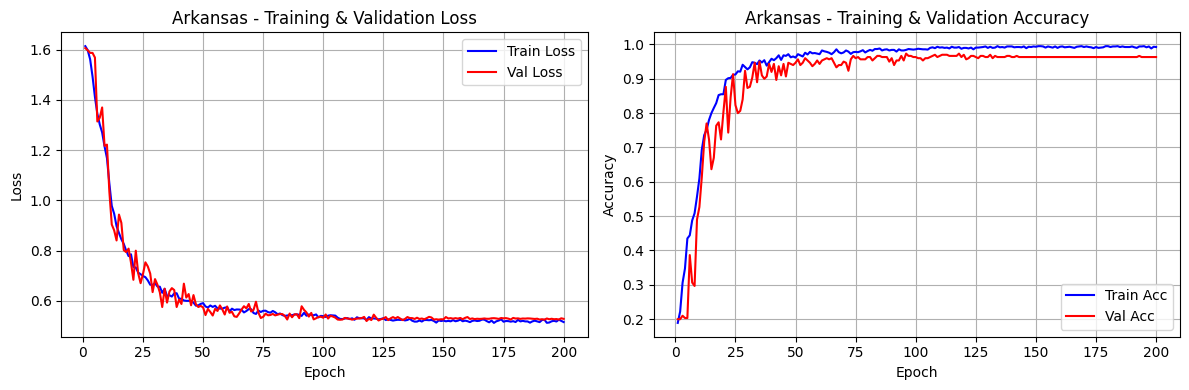

In [ ]:
import matplotlib.pyplot as plt
import os
from google.colab import drive


drive.mount('/content/drive')


save_folder = '/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs'
os.makedirs(save_folder, exist_ok=True)


epochs = range(1, len(history_plus['train_loss']) + 1)


plt.figure(figsize=(12, 4))

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_plus['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs, history_plus['val_loss'], 'r-', label='Val Loss')
plt.title('Arkansas - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_plus['train_acc'], 'b-', label='Train Acc')
plt.plot(epochs, history_plus['val_acc'], 'r-', label='Val Acc')
plt.title('Arkansas - Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()

# Sauvegarder AVANT d'afficher
filepath = os.path.join(save_folder, 'arkansas_training_curves.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f" Graphique sauvegardé dans : {filepath}")


plt.show()





### **CALIFORNIA**

In [ ]:
# ============================================
# FONCTION train_state POUR CALIFORNIA
# ============================================

def train_state_ca(model, train_loader, val_loader, test_loader, device, state_name,
                   epochs=200, lr=0.001, weight_decay=1e-2):
    """
    Entraîne un modèle avec CrossEntropyLoss, LR constant, pas de scheduler.
    Retourne modèle, historique, métriques, matrice confusion.
    """
    criterion = nn.CrossEntropyLoss()
    label_smoothing=0.05
    # ← au lieu de LabelSmoothingLoss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Pas de scheduler

    best_val_acc = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch_plus(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_plus(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{state_name.lower()}_mctnetplus.pth')

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | Best Val Acc: {best_val_acc:.4f}")

    print(f"\n Meilleure validation {state_name}: Acc = {best_val_acc:.4f}")

    # Évaluation sur le test avec le meilleur modèle
    model.load_state_dict(torch.load(f'best_{state_name.lower()}_mctnetplus.pth'))
    test_loss, test_acc = evaluate_plus(model, test_loader, criterion, device)

    # Matrice de confusion et rapport
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            mask = create_mask(X)
            out = model(X, mask)
            preds = out.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=target_classes)

    metrics = {'test_loss': test_loss, 'test_acc': test_acc, 'confusion_matrix': cm, 'report': report}
    return model, history, metrics, cm


# ============================================
# 1. CHARGEMENT DES DONNÉES CALIFORNIA
# ============================================
print("\n" + "="*60)
print("ENTRAÎNEMENT MCTNet++ - CALIFORNIA")
print("="*60)

# Charger les données
X_train, _, X_val, _, X_test, _, metadata = load_data_with_correct_split("california")

# Classes cibles pour la Californie
target_classes = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

# Récupérer les noms des classes depuis metadata
y_train_raw = metadata['y_train_names']
y_val_raw   = metadata['y_val_names']
y_test_raw  = metadata['y_test_names']

# Filtrer (normalement tous les échantillons sont déjà dans target_classes)
train_mask = np.isin(y_train_raw, target_classes)
val_mask   = np.isin(y_val_raw, target_classes)
test_mask  = np.isin(y_test_raw, target_classes)

X_train_f = X_train[train_mask]
y_train_f = y_train_raw[train_mask]
X_val_f   = X_val[val_mask]
y_val_f   = y_val_raw[val_mask]
X_test_f  = X_test[test_mask]
y_test_f  = y_test_raw[test_mask]

print(f"Après filtrage pour {target_classes}:")
print(f"   Train: {X_train_f.shape[0]} samples")
print(f"   Val  : {X_val_f.shape[0]} samples")
print(f"   Test : {X_test_f.shape[0]} samples")

# Convertir les noms en indices
class_to_idx = {cls: i for i, cls in enumerate(target_classes)}
y_train = np.array([class_to_idx[name] for name in y_train_f])
y_val   = np.array([class_to_idx[name] for name in y_val_f])
y_test  = np.array([class_to_idx[name] for name in y_test_f])
num_classes = len(target_classes)

print(f"\nDistribution des classes (train) :")
for cls in target_classes:
    cnt = np.sum(y_train_f == cls)
    print(f"   {cls}: {cnt}")

# ============================================
# 2. NORMALISATION PAR ÉCHANTILLON
# ============================================
def normalize_per_sample(X):
    mean = X.mean(axis=(1,2), keepdims=True)
    std  = X.std(axis=(1,2), keepdims=True)
    return (X - mean) / (std + 1e-8)

X_train_norm = normalize_per_sample(X_train_f)
X_val_norm   = normalize_per_sample(X_val_f)
X_test_norm  = normalize_per_sample(X_test_f)

print(f"Stats après normalisation: min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}, mean={X_train_norm.mean():.2f}")

# ============================================
# 3. DATALOADERS
# ============================================
BATCH_SIZE = 128

train_dataset = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y_train))
val_dataset   = TensorDataset(torch.FloatTensor(X_val_norm),   torch.LongTensor(y_val))
test_dataset  = TensorDataset(torch.FloatTensor(X_test_norm),  torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ca = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================
# 4. MODÈLE MCTNet++
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")





model = MCTNetPlus(
    input_dim   = X_train_norm.shape[2],
    seq_len     = X_train_norm.shape[1],
    num_classes = num_classes,
    nhead       = 4,
    dropout_rate= 0.6,
    h1=8, h2=16, h3=32
).to(device)

print(f"Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")

# ============================================
# 5. ENTRAÎNEMENT
# ============================================
EPOCHS = 200
LR = 0.001
WEIGHT_DECAY = 1e-2

model_plus_ca, history_ca, metrics_ca, cm_ca = train_state_ca(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader_ca,
    device=device,
    state_name="California",
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY

)

print(f"\nTest Acc MCTNet++ California : {metrics_ca['test_acc']:.4f}")
print("\nClassification Report :")
print(metrics_ca['report'])


ENTRAÎNEMENT MCTNet++ - CALIFORNIA

california:
   - Train: 1440 samples
   - Val: 360 samples
   - Test: 8200 samples
   - Shape: 36 timesteps, 10 bands

   Distribution RÉELLE (train) :
      Grapes: 240
      Rice: 240
      Alfalfa: 240
      Almonds: 240
      Pistachios: 240
      Others: 240
Après filtrage pour ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']:
   Train: 1440 samples
   Val  : 360 samples
   Test : 8200 samples

Distribution des classes (train) :
   Grapes: 240
   Rice: 240
   Alfalfa: 240
   Almonds: 240
   Pistachios: 240
   Others: 240
Stats après normalisation: min=-3.94, max=5.83, mean=0.00

Device: cpu
Nombre de paramètres: 61,997
Epoch  20/200 | Train Loss: 0.9257 Acc: 0.6062 | Val Loss: 1.3312 Acc: 0.4333 | Best Val Acc: 0.5639
Epoch  40/200 | Train Loss: 0.6822 Acc: 0.7347 | Val Loss: 0.9163 Acc: 0.6611 | Best Val Acc: 0.6917
Epoch  60/200 | Train Loss: 0.5920 Acc: 0.7833 | Val Loss: 0.7293 Acc: 0.7500 | Best Val Acc: 0.7806
Epoch  80/20

# **Plots CALIFORNIA**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Graphique sauvegardé dans : /content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs/california_training_curves.png


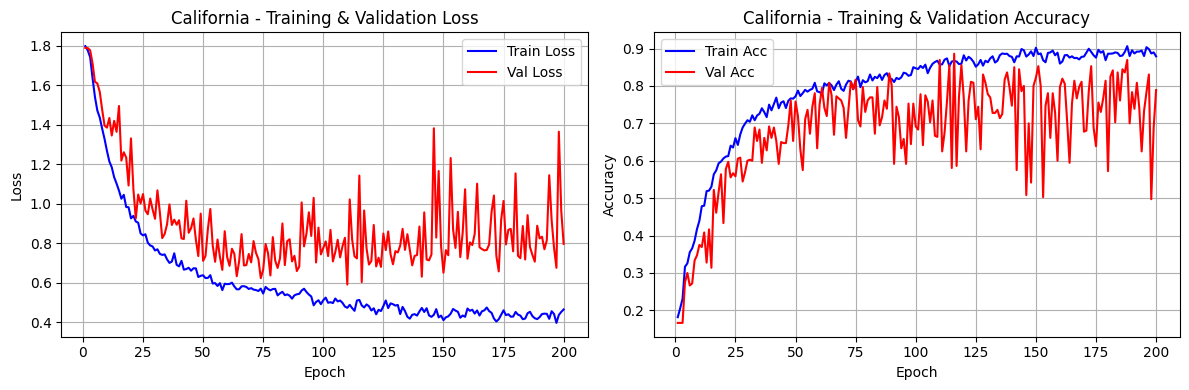

In [ ]:
import matplotlib.pyplot as plt
import os
from google.colab import drive


drive.mount('/content/drive')


save_folder = '/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs'
os.makedirs(save_folder, exist_ok=True)


epochs = range(1, len(history_ca['train_loss']) + 1)

plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history_ca['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs, history_ca['val_loss'], 'r-', label='Val Loss')
plt.title('California - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history_ca['train_acc'], 'b-', label='Train Acc')
plt.plot(epochs, history_ca['val_acc'], 'r-', label='Val Acc')
plt.title('California - Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()


filepath = os.path.join(save_folder, 'california_training_curves.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f" Graphique sauvegardé dans : {filepath}")

plt.show()

# **PART2 DATASET**



In [ ]:
PROCESSED_DIR = '/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/processed'

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

N_TIMES = 36
N_BANDS = 10
PROCESSED_DIR = '/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/data'
ENV_VARS = ['bio01_temp', 'bio12_precip', 'bio15_precip_season', 'elevation', 'landforms', 'soil_clay', 'soil_oc', 'soil_ph']

class CropDataset(Dataset):
    def __init__(self, state_name, split, env_vars):
        """
        state_name : 'california' ou 'arkansas'
        split      : 'train', 'val' ou 'test'
        env_vars   : liste des noms des covariables à utiliser (ex: ENV_VARS ou sous-ensemble)
        """
        split_dir = os.path.join(PROCESSED_DIR, 'splits', state_name)

        X_s2 = np.load(os.path.join(split_dir, 'X_s2.npy'))
        X_env_all = np.load(os.path.join(split_dir, 'X_env.npy'))
        y = np.load(os.path.join(split_dir, 'y.npy'))

        idx = np.load(os.path.join(split_dir, f'{split}_idx.npy'))


        X_s2 = X_s2[idx]
        X_env = X_env_all[idx]
        y = y[idx]


        if env_vars:
            env_indices = [ENV_VARS.index(v) for v in env_vars if v in ENV_VARS]
            X_env = X_env[:, env_indices]
        else:
            X_env = np.zeros((len(idx), 0), dtype=np.float32)


        self.X_s2 = torch.tensor(X_s2, dtype=torch.float32)
        self.X_env = torch.tensor(X_env, dtype=torch.float32) if X_env.shape[1] > 0 else torch.zeros(len(idx), 0, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.n_env = X_env.shape[1]


        s2_reshaped = self.X_s2.view(-1, N_TIMES, N_BANDS)


        if self.n_env > 0:
            env_repeated = self.X_env.unsqueeze(1).repeat(1, N_TIMES, 1)
            self.X_combined = torch.cat([s2_reshaped, env_repeated], dim=-1)
        else:
            self.X_combined = s2_reshaped


        self.mask = (s2_reshaped.abs().sum(dim=-1) > 0).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_combined[idx],
            self.mask[idx],
            self.y[idx]
        )

In [ ]:
train_ds = CropDataset(state_name='california', split='train', env_vars=ENV_VARS)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_TIMES = 36
N_BANDS = 10
BATCH_SIZE = 32



CLIMATE_VARS = ['bio01_temp', 'bio12_precip', 'bio15_precip_season']
SOIL_VARS    = ['soil_ph', 'soil_oc', 'soil_clay']
TOPO_VARS    = ['elevation', 'landforms']
ENV_VARS     = CLIMATE_VARS + SOIL_VARS + TOPO_VARS

CONFIGS = [
    {'name':'Config 1 — S2 only (Baseline)',   'short':'Baseline (S2)',   'env_cols':[]},
    {'name':'Config 2 — S2 + Climat',          'short':'S2+Climat',       'env_cols':CLIMATE_VARS},
    {'name':'Config 3 — S2 + Sol',             'short':'S2+Sol',          'env_cols':SOIL_VARS},
    {'name':'Config 4 — S2 + Topographie',     'short':'S2+Topo',         'env_cols':TOPO_VARS},
    {'name':'Config 5 — S2 + All Covariables', 'short':'S2+All',          'env_cols':ENV_VARS},
]

def train_model(model, train_loader, val_loader, epochs=200, lr=0.001, patience=25):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    best_loss, best_state, no_imp = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        model.train()
        tl = 0
        for x_combined, mk, lb in train_loader:
            x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
            optimizer.zero_grad()
            out = model(x_combined, mk)
            loss = criterion(out, lb)
            loss.backward()
            optimizer.step()
            tl += loss.item()
        model.eval()
        vl, vp, vt = 0, [], []
        with torch.no_grad():
            for x_combined, mk, lb in val_loader:
                x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
                out = model(x_combined, mk)
                vl += criterion(out, lb).item()
                vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(lb.cpu().numpy())
        avg_vl = vl/len(val_loader)
        va = accuracy_score(vt, vp)
        scheduler.step(avg_vl)
        history['train_loss'].append(tl/len(train_loader))
        history['val_loss'].append(avg_vl)
        history['val_acc'].append(va)
        if avg_vl < best_loss:
            best_loss = avg_vl
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f'  Early stopping — epoch {epoch}')
            break
        if epoch % 25 == 0:
            print(f'  E{epoch:3d} | TLoss={tl/len(train_loader):.4f} | VLoss={avg_vl:.4f} | VAcc={va:.4f}')
    model.load_state_dict(best_state)
    return model, history

def evaluate_model(model, test_loader):
    model.eval()
    ap, at = [], []
    with torch.no_grad():
        for x_combined, mk, lb in test_loader:
            out = model(x_combined.to(DEVICE), mk.to(DEVICE))
            ap.extend(out.argmax(1).cpu().numpy())
            at.extend(lb.numpy())
    return {
        'OA'   : accuracy_score(at, ap),
        'Kappa': cohen_kappa_score(at, ap),
        'F1'   : f1_score(at, ap, average='macro'),
        'CM'   : confusion_matrix(at, ap),
    }

states = ['california', 'arkansas']
all_results = {}
all_histories = {}

for state_name in states:
    print(f"\n{'#'*60}")
    print(f"  ÉTAT : {state_name.upper()}")
    print(f"{'-'*60}")
    num_classes = 6 if state_name == 'california' else 5
    all_results[state_name] = {}
    all_histories[state_name] = {}
    for cfg in CONFIGS:
        print(f'\n   {cfg["name"]}')
        train_ds = CropDataset(state_name, 'train', cfg['env_cols'])
        val_ds   = CropDataset(state_name, 'val',   cfg['env_cols'])
        test_ds  = CropDataset(state_name, 'test',  cfg['env_cols'])
        train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
        test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
        input_dim = N_BANDS + len(cfg['env_cols'])
        model = MCTNetPlus(
            input_dim=input_dim,
            seq_len=N_TIMES,
            num_classes=num_classes,
            nhead=5,
            dropout_rate=0.4,
            h1=10, h2=20, h3=40
        ).to(DEVICE)
        model, history = train_model(model, train_ld, val_ld, epochs=200, lr=0.001, patience=25)
        res = evaluate_model(model, test_ld)
        res['n_params'] = sum(p.numel() for p in model.parameters())
        all_results[state_name][cfg['name']] = res
        all_histories[state_name][cfg['name']] = history
        print(f'     OA={res["OA"]:.4f} | Kappa={res["Kappa"]:.4f} | F1={res["F1"]:.4f} | Params={res["n_params"]:,}')




############################################################
  ÉTAT : CALIFORNIA
------------------------------------------------------------

   Config 1 — S2 only (Baseline)
  E 25 | TLoss=0.2724 | VLoss=0.4482 | VAcc=0.8958
  Early stopping — epoch 40
     OA=0.9048 | Kappa=0.8595 | F1=0.6837 | Params=93,180

   Config 2 — S2 + Climat
  E 25 | TLoss=0.3087 | VLoss=0.5208 | VAcc=0.8667
  E 50 | TLoss=0.1339 | VLoss=0.5036 | VAcc=0.9000
  Early stopping — epoch 62
     OA=0.9377 | Kappa=0.9068 | F1=0.7194 | Params=93,320

   Config 3 — S2 + Sol
  E 25 | TLoss=0.2780 | VLoss=0.5102 | VAcc=0.8667
  Early stopping — epoch 46
     OA=0.9143 | Kappa=0.8731 | F1=0.6949 | Params=93,320

   Config 4 — S2 + Topographie
  E 25 | TLoss=0.2980 | VLoss=0.4206 | VAcc=0.8958
  Early stopping — epoch 47
     OA=0.9151 | Kappa=0.8745 | F1=0.7015 | Params=93,310

   Config 5 — S2 + All Covariables
  E 25 | TLoss=0.2530 | VLoss=0.3458 | VAcc=0.9000
  E 50 | TLoss=0.1649 | VLoss=0.3327 | VAcc=0.9042
  E

# **AFFICHAGE FINAL : ACCURACY (OA), KAPPA, F1**

In [ ]:

print("\n" + "="*80)
print(" RÉSULTATS FINAUX - MEILLEURE CONFIGURATION PAR ÉTAT")
print("="*80)

for state in states:

    base = all_results[state][CONFIGS[0]['name']]

    best_cfg = max(CONFIGS[1:], key=lambda c: all_results[state][c['name']]['OA'])
    best = all_results[state][best_cfg['name']]

    print(f"\n📍 {state.upper()} (nombre de classes : {6 if state=='california' else 5})")
    print(f"   Baseline (S2 seul) :")
    print(f"      OA    = {base['OA']:.4f}")
    print(f"      Kappa = {base['Kappa']:.4f}")
    print(f"      F1    = {base['F1']:.4f}")
    print(f"\n   Meilleure configuration : {best_cfg['short']}")
    print(f"      OA    = {best['OA']:.4f}")
    print(f"      Kappa = {best['Kappa']:.4f}")
    print(f"      F1    = {best['F1']:.4f}")
    print(f"      Gain en OA : +{(best['OA'] - base['OA'])*100:.2f} points")

print("\n Étude d'ablation terminée.")


 RÉSULTATS FINAUX - MEILLEURE CONFIGURATION PAR ÉTAT

📍 CALIFORNIA (nombre de classes : 6)
   Baseline (S2 seul) :
      OA    = 0.9048
      Kappa = 0.8595
      F1    = 0.6837

   Meilleure configuration : S2+All
      OA    = 0.9631
      Kappa = 0.9444
      F1    = 0.7451
      Gain en OA : +5.83 points

📍 ARKANSAS (nombre de classes : 5)
   Baseline (S2 seul) :
      OA    = 0.9721
      Kappa = 0.9537
      F1    = 0.9577

   Meilleure configuration : S2+Sol
      OA    = 0.9658
      Kappa = 0.9433
      F1    = 0.9522
      Gain en OA : +-0.62 points

✅ Étude d'ablation terminée.


In [ ]:
def train_model_full(model, train_loader, val_loader, epochs=200, lr=0.001, patience=25):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    best_loss, best_state, no_imp = float('inf'), None, 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        model.train()
        tl = 0
        correct_train = 0
        total_train = 0
        for x_combined, mk, lb in train_loader:
            x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
            optimizer.zero_grad()
            out = model(x_combined, mk)
            loss = criterion(out, lb)
            loss.backward()
            optimizer.step()
            tl += loss.item()
            _, pred = out.max(1)
            total_train += lb.size(0)
            correct_train += pred.eq(lb).sum().item()
        train_acc = correct_train / total_train
        model.eval()
        vl, vp, vt = 0, [], []
        with torch.no_grad():
            for x_combined, mk, lb in val_loader:
                x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
                out = model(x_combined, mk)
                vl += criterion(out, lb).item()
                vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(lb.cpu().numpy())
        avg_vl = vl/len(val_loader)
        va = accuracy_score(vt, vp)
        scheduler.step(avg_vl)
        history['train_loss'].append(tl/len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_vl)
        history['val_acc'].append(va)
        if avg_vl < best_loss:
            best_loss = avg_vl
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f'  Early stopping — epoch {epoch}')
            break
        if epoch % 25 == 0:
            print(f'  E{epoch:3d} | TLoss={tl/len(train_loader):.4f} | TAcc={train_acc:.4f} | VLoss={avg_vl:.4f} | VAcc={va:.4f}')
    model.load_state_dict(best_state)
    return model, history

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graphique sauvegardé : /content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs/california_S2+All_training_curves.png


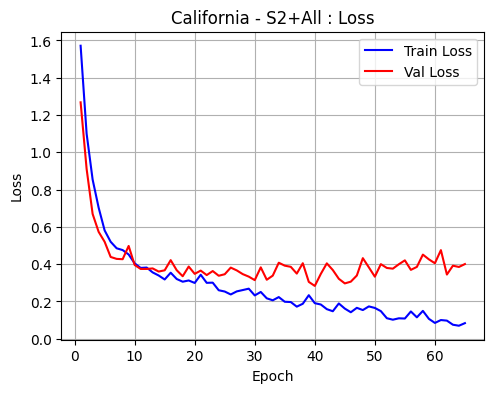

Graphique sauvegardé : /content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs/arkansas_S2+All_training_curves.png


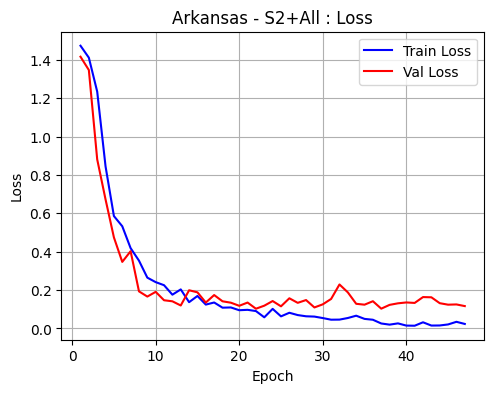

In [ ]:
import matplotlib.pyplot as plt
import os
from google.colab import drive


drive.mount('/content/drive')


save_folder = '/content/drive/MyDrive/datasetRESNEUR/Crop_Classification/outputs'
os.makedirs(save_folder, exist_ok=True)


CONFIGS = [
    {'name': 'Config 1 — S2 only (Baseline)',   'short': 'S2 seul',      'env_cols': []},
    {'name': 'Config 2 — S2 + Climat',          'short': 'S2+Climat',    'env_cols': CLIMATE_VARS},
    {'name': 'Config 3 — S2 + Sol',             'short': 'S2+Sol',       'env_cols': SOIL_VARS},
    {'name': 'Config 4 — S2 + Topographie',     'short': 'S2+Topo',      'env_cols': TOPO_VARS},
    {'name': 'Config 5 — S2 + All Covariables', 'short': 'S2+All',       'env_cols': ENV_VARS},
]

states = ['california', 'arkansas']


for state in states:

    cfg_name = CONFIGS[4]['name']
    history = all_histories[state][cfg_name]

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title(f'{state.capitalize()} - S2+All : Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)



    # Sauvegarde
    filepath = os.path.join(save_folder, f'{state}_S2+All_training_curves.png')
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Graphique sauvegardé : {filepath}")
    plt.show()